# Goals

📄 Resume-Driven Questions: Parse an uploaded resume to ask highly relevant questions about projects and experiences.

🎯 Goal-Oriented Interviews: Allow users to specify target roles (e.g., Data Analyst, ML Engineer), prompting the agent to tailor the interview questions and focus.

⚖️ Dynamic Difficulty Adjustment: The agent escalates or de-escalates question complexity based on user performance.

🗣️ Enhanced Behavioral Feedback: A sub-agent could analyze the structure and delivery of answers (e.g., STAR method adherence, clarity, conciseness).

In [9]:
import os, getpass
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
os.environ["LANGCHAIN_PROJECT"] = "langchain-academy"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
from langchain_google_genai import ChatGoogleGenerativeAI
from pdfminer.high_level import extract_text
model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
from langchain_core.prompts import ChatPromptTemplate
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, BaseMessage, AnyMessage
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Any, Optional
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END


In [10]:
model.invoke("Hello, gemini").content

'Hello! How can I help you today?'

## Reading a CV

## Chatbot with memory and cv info

In [11]:
class OverallState(BaseModel):
    messages: list[AnyMessage] = Field(description="A list of Langchain messages from the past conversation")
    cv: Optional[str] = Field(descrixption="A string containing professional and academic background of a candidate")
    score: Optional[int] = Field(description="A number ranging from 0 to 10, depending on how good the las answer from the human was")
    num_questions: int = Field(description="Number of questions asked to the human")
    

In [12]:
chatbot_prompt = '''
   You are a technical interviewer for an AI Engineer role. You're interviewing a person with the cv {cv}, and this is your past conversation:
   {past_messages}

   Based on the conversation and CV, provide a question related to the role and the cv of the candidate
   '''
scoring_prompt = '''
   {cv}
   {past_messages}

   Based on the conversation and CV, provide a numeric score, based on how exact last's answer was.

   The answer must be an integer, ranging from 0 to 10. Always follow this format. NEVER PROVIDE ANYTHING THAT IS NOT A NUMBER
   '''

ender_prompt = '''
   {cv}
   {past_messages}
   {score}

   Based on the conversation, CV and score of the previous answers, end the conversation with the human in a warm but professional way. 
   Inform the human that the conversation is over, and make a justified decision on whether to hire the candidate or not.
   '''

In [13]:
def cv_reader(state:OverallState):
    cv_path = '../data/adaptive_agent/RGG-English.pdf'
    print("Reading your CV...")
    text_content = extract_text(cv_path)
    return{"cv":text_content}

def chatbot(state: OverallState):
    print("Preparing an answer")
    chat_prompt = ChatPromptTemplate.from_template(chatbot_prompt)
    chat_chain = chat_prompt | model
    score_prompt = ChatPromptTemplate.from_template(scoring_prompt)
    score_chain = score_prompt | model
    
    # Pass the variables as a dict
    chat_response = chat_chain.invoke({"cv": state.cv, "past_messages": state.messages})
    score_response = score_chain.invoke({"cv": state.cv, "past_messages": state.messages})
    # print(chat_response)
    # print(score_response)
    print(f"Score: {score_response.content}")
    print(f"Chatbot: {chat_response.content}")

    all_msg = state.messages + [AIMessage(content=chat_response.content)]
    
    
    return OverallState(
        messages=all_msg,
        cv=state.cv,
        score=int(score_response.content),
        num_questions= state.num_questions + 1
    )

def human_response(state: OverallState):
    response = input("Enter your response: ")
    all_msg = state.messages + [HumanMessage(content=response)]

    print(f"Human: {response}")

    return OverallState(messages=all_msg, cv=state.cv, score = state.score, num_questions=state.num_questions)

def questions_condition(state: OverallState):
    if state.num_questions <= 2:
        return "chatbot"
    else:
        return "chatbot_ender"

def chatbot_ender(state: OverallState):
    ending_prompt = ChatPromptTemplate.from_template(ender_prompt)
    ender_chain = ending_prompt | model
    response = ender_chain.invoke({"cv": state.cv, "past_messages": state.messages, "score": state.score})
    print(f"Ending: {response.content}")
    all_msg = state.messages + [AIMessage(content=response.content)]

    return OverallState(messages = all_msg, cv=state.cv, score = state.score, num_questions=state.num_questions)
    


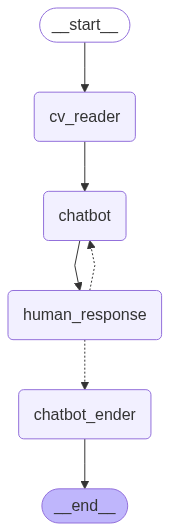

In [14]:
builder = StateGraph(OverallState)
builder.add_node("cv_reader", cv_reader)
builder.add_node("chatbot", chatbot)
builder.add_node("human_response", human_response)
builder.add_node("chatbot_ender", chatbot_ender)


builder.add_edge(START, "cv_reader")
builder.add_edge("cv_reader", "chatbot")
builder.add_edge("chatbot", "human_response")
builder.add_conditional_edges("human_response", questions_condition, {"chatbot":"chatbot","chatbot_ender":"chatbot_ender" })
builder.add_edge( "chatbot_ender", END)
# builder.add_edge("chatbot", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
response = graph.invoke(OverallState(messages=[HumanMessage(content="Hello, glad to be here")],cv="",score=5, num_questions=0))

Reading your CV...
Preparing an answer
Score: 10
Chatbot: Okay, Raúl, thanks for being here. Your CV shows a strong foundation in IT and a recent focus on AI through the bootcamp.

**Given your experience with CRM and ERP implementations at Edison Next Spain, and your recent training in LLMs and LangChain, how do you envision applying LLMs to improve or innovate within CRM/ERP systems? Can you provide a specific example of a problem you think LLMs could solve in that context and how you might approach it?**
Human: 
Preparing an answer
Score: 0
Chatbot: Okay, Raúl, you mentioned experience with both SQL and MongoDB in your bootcamp. Considering your background in economics and experience with CRM/ERP systems, **can you describe a scenario where you might choose MongoDB over SQL for storing and processing data within a CRM or ERP system, and why? What are the specific advantages MongoDB would offer in that situation?**
Human: 
Preparing an answer
Score: 0
Chatbot: Okay, Raúl, based on yo